# 🌾 Crop Recommendation System

A machine learning system that recommends the most suitable crop to cultivate based on soil nutrients (N, P, K) and environmental conditions (temperature, humidity, pH, rainfall).

**Pipeline covered in this notebook:**
1. Data Loading & Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Model Training (Decision Tree, Random Forest, KNN, Naive Bayes, SVM, Logistic Regression)
4. Model Evaluation & Comparison
5. Prediction on New Input Values


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

**Dataset:** [Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset) (Kaggle)

It contains 2200 samples across 22 crop types, with 7 numeric features:
- `N`, `P`, `K` — ratio of Nitrogen, Phosphorus, Potassium content in soil
- `temperature` — °C
- `humidity` — relative humidity %
- `ph` — soil pH value
- `rainfall` — mm


In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
csv_path = os.path.join(path, "Crop_recommendation.csv")
df = pd.read_csv(csv_path)
df.head()

100%|██████████| 63.7k/63.7k [00:00<00:00, 257kB/s]

Extracting files...


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Exploratory Data Analysis (EDA)

### 3.1 Shape, dtypes & missing values

In [3]:
print("Shape:", df.shape)
df.info()
print("\nMissing values per column:\n", df.isnull().sum())


Shape: (2200, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB

Missing values per column:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### 3.2 Target class balance
The dataset is perfectly balanced — 100 samples for each of the 22 crops.

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


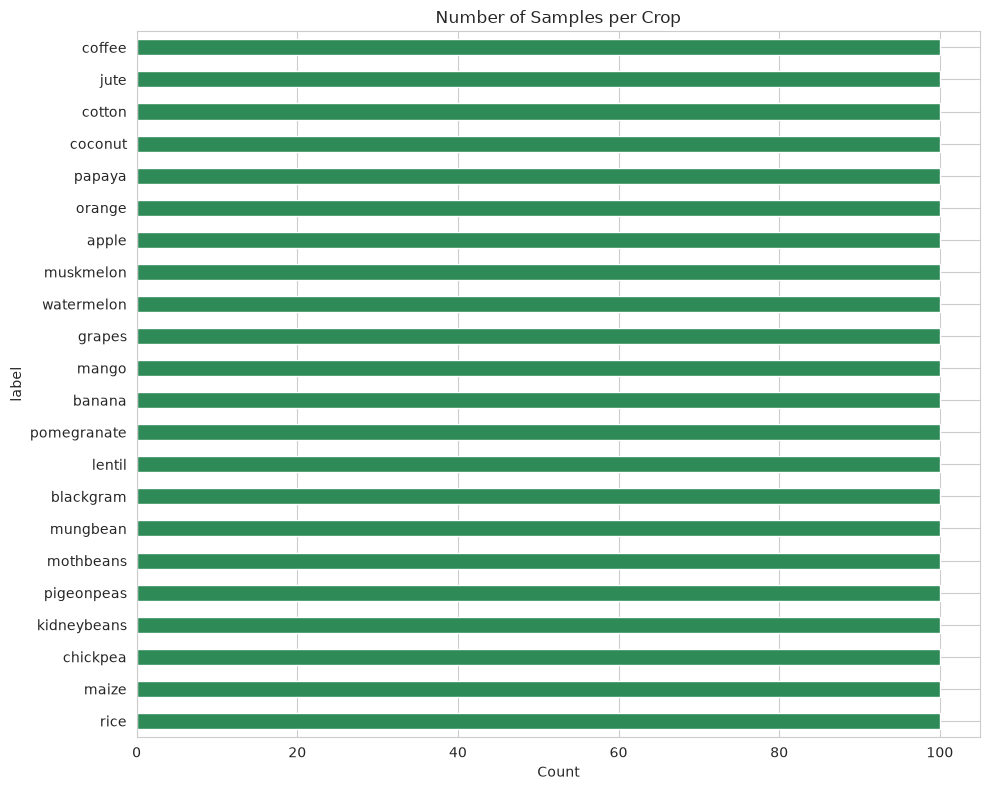

In [4]:
print(df['label'].value_counts())

plt.figure(figsize=(10, 8))
df['label'].value_counts().plot(kind='barh', color='seagreen')
plt.title("Number of Samples per Crop")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


### 3.3 Summary statistics

In [5]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### 3.4 Correlation between features

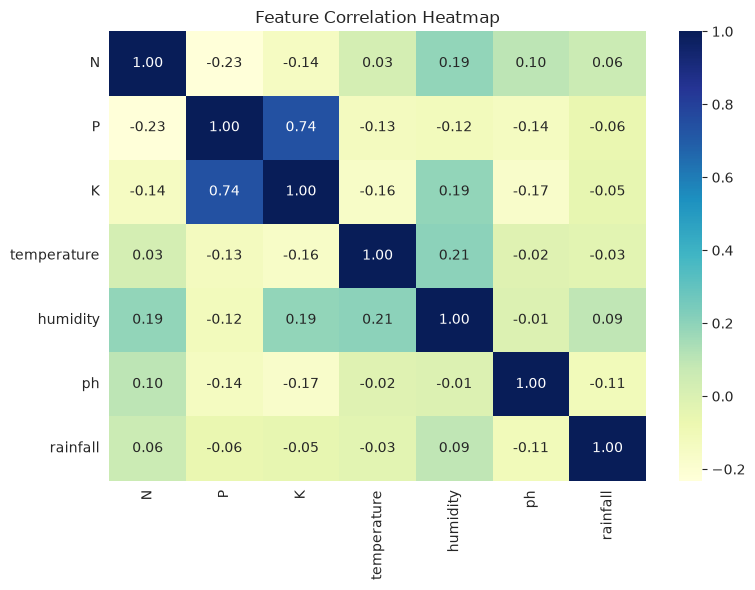

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


### 3.5 Feature distributions by crop (sample)
Example: rainfall and humidity requirements vary a lot between crops such as rice, coffee and grapes.

/tmp/ipykernel_13279/262105466.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='label', y='rainfall', ax=axes[0], palette='Set2')
/tmp/ipykernel_13279/262105466.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='label', y='humidity', ax=axes[1], palette='Set2')


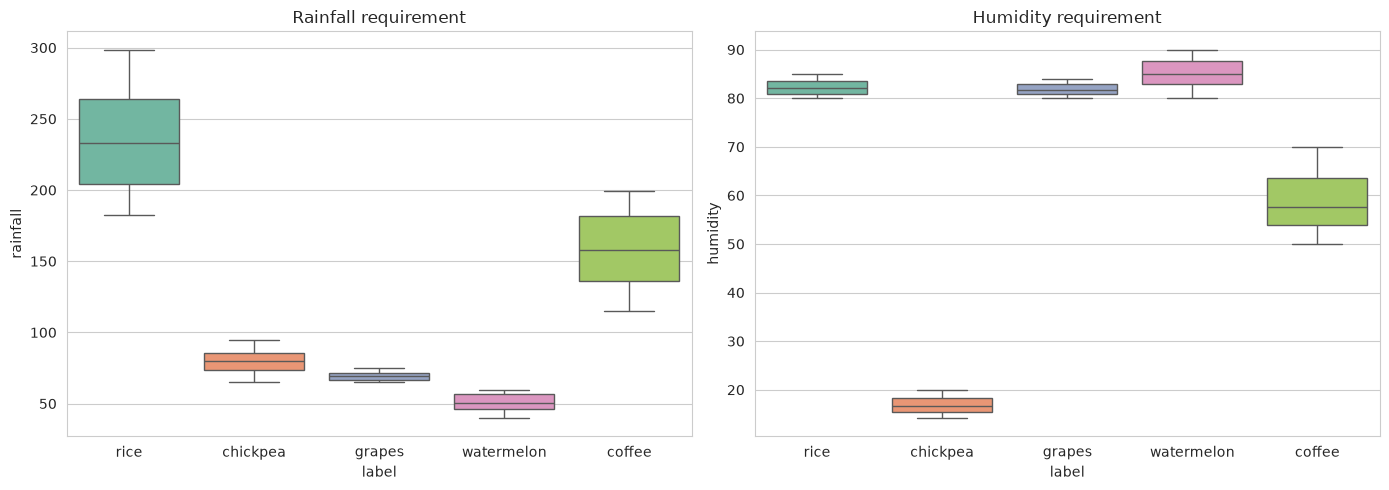

In [7]:
sample_crops = ['rice', 'coffee', 'grapes', 'watermelon', 'chickpea']
subset = df[df['label'].isin(sample_crops)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=subset, x='label', y='rainfall', ax=axes[0], palette='Set2')
axes[0].set_title("Rainfall requirement")
sns.boxplot(data=subset, x='label', y='humidity', ax=axes[1], palette='Set2')
axes[1].set_title("Humidity requirement")
plt.tight_layout()
plt.show()


## 4. Feature Engineering

- Encode the target crop `label` into numeric classes with `LabelEncoder`.
- Split into train/test sets (80/20, stratified so every crop is represented proportionally).
- Standardize features for the distance/margin-based models (KNN, SVM, Logistic Regression). Tree-based models (Decision Tree, Random Forest) are scale-invariant, so they use the raw features.


In [8]:
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1760, 7)  Test shape: (440, 7)


## 5. Model Training

We train and compare several classification algorithms:
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Support Vector Machine (SVM)
- Logistic Regression


In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}

scaled_models = {"KNN", "SVM", "Logistic Regression"}

results = {}
trained_models = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, scaler.fit_transform(X), y_encoded, cv=5)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        cv_scores = cross_val_score(model, X, y_encoded, cv=5)

    test_acc = accuracy_score(y_test, preds)
    results[name] = {"test_accuracy": test_acc, "cv_accuracy": cv_scores.mean()}
    trained_models[name] = model
    print(f"{name:22s} | Test Accuracy: {test_acc:.4f} | 5-Fold CV Accuracy: {cv_scores.mean():.4f}")


Decision Tree          | Test Accuracy: 0.9795 | 5-Fold CV Accuracy: 0.9868
Random Forest          | Test Accuracy: 0.9955 | 5-Fold CV Accuracy: 0.9945
KNN                    | Test Accuracy: 0.9795 | 5-Fold CV Accuracy: 0.9714
Naive Bayes            | Test Accuracy: 0.9955 | 5-Fold CV Accuracy: 0.9950
SVM                    | Test Accuracy: 0.9841 | 5-Fold CV Accuracy: 0.9823
Logistic Regression    | Test Accuracy: 0.9727 | 5-Fold CV Accuracy: 0.9714


## 6. Model Evaluation & Comparison

In [10]:
results_df = pd.DataFrame(results).T.sort_values('test_accuracy', ascending=False)
results_df


,test_accuracy,cv_accuracy
Random Forest,0.995455,0.994545
Naive Bayes,0.995455,0.995000
SVM,0.984091,0.982273
Decision Tree,0.979545,0.986818
KNN,0.979545,0.971364
Logistic Regression,0.972727,0.971364


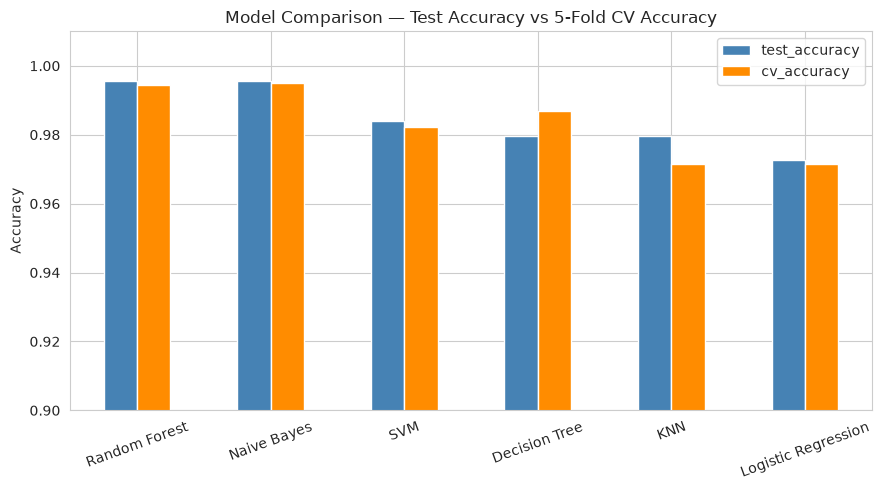

In [11]:
results_df[['test_accuracy', 'cv_accuracy']].plot(kind='bar', figsize=(9, 5), color=['steelblue', 'darkorange'])
plt.title("Model Comparison — Test Accuracy vs 5-Fold CV Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.01)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 6.1 Closer look at the best model

In [12]:
best_name = results_df.index[0]
best_model = trained_models[best_name]
print("Best model:", best_name)

if best_name in scaled_models:
    best_preds = best_model.predict(X_test_scaled)
else:
    best_preds = best_model.predict(X_test)

print(classification_report(y_test, best_preds, target_names=le.classes_))


Best model: Random Forest
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
 

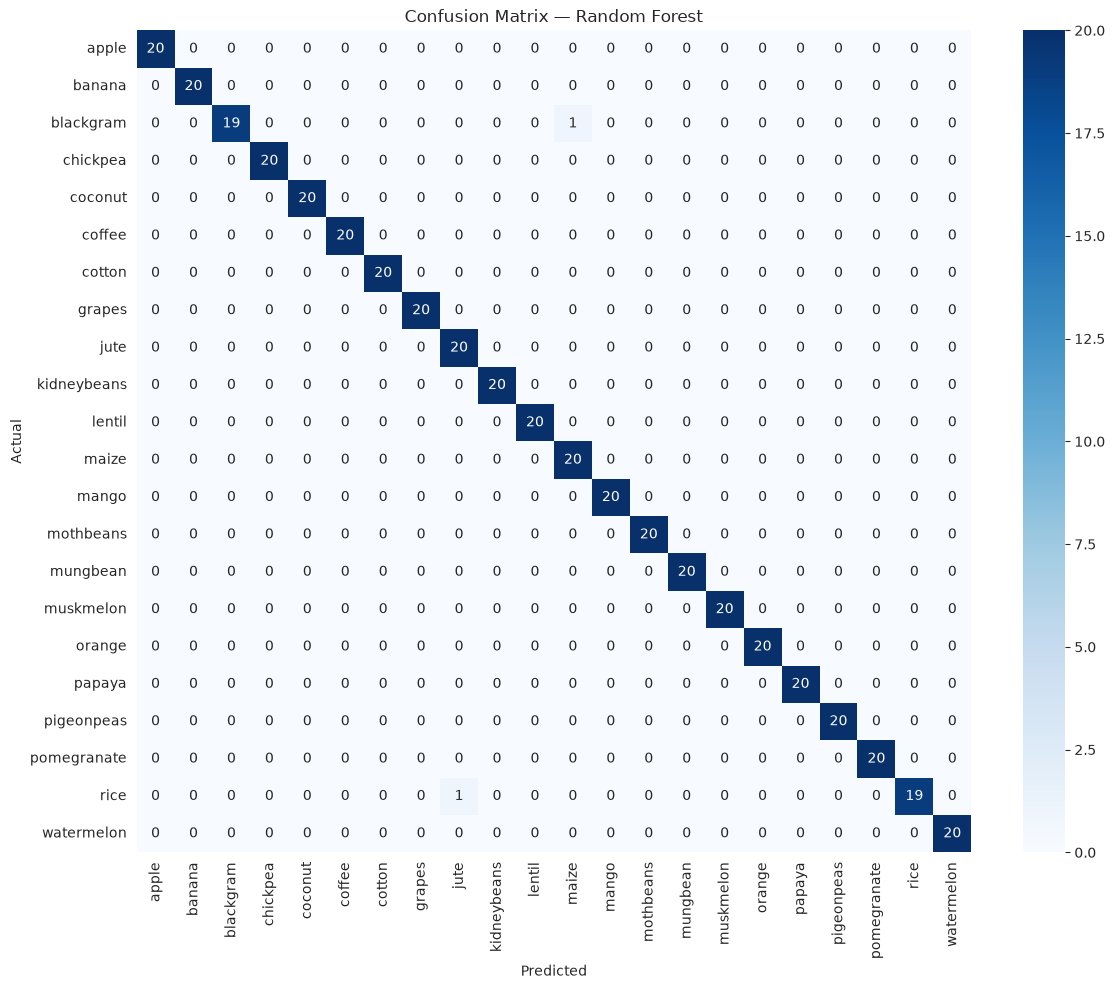

In [13]:
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 6.2 Feature importance (Random Forest)
Which soil/environmental factors matter most for crop choice?

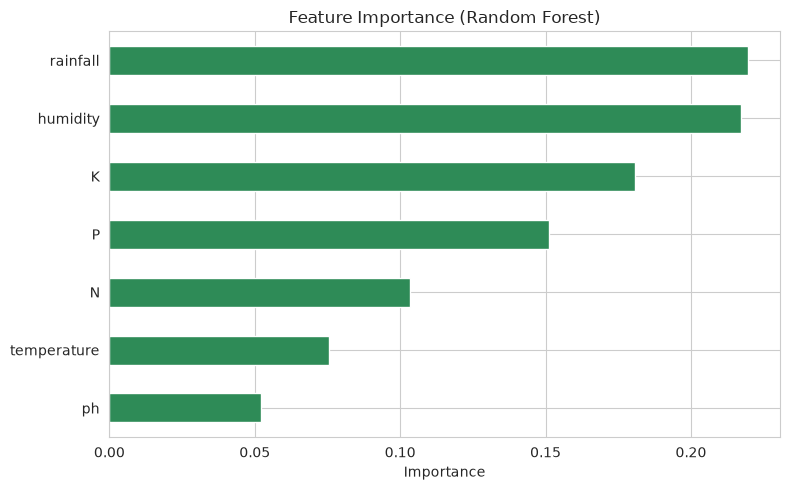

rainfall       0.219641
humidity       0.217058
K              0.180813
P              0.151342
N              0.103356
temperature    0.075485
ph             0.052305
dtype: float64

In [14]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 7. Save the Best Model
We persist the trained model, the label encoder, and the scaler so they can be reused for prediction without retraining.


In [17]:
import os
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/crop_recommendation_model.pkl")
joblib.dump(le, "model/label_encoder.pkl")
joblib.dump(scaler, "model/scaler.pkl")
print(f"Saved '{best_name}' model and preprocessing objects to the 'model/' directory.")


Saved 'Random Forest' model and preprocessing objects to the 'model/' directory.


## 8. Prediction on New Input Values

Given new values for N, P, K, temperature, humidity, ph, and rainfall, predict the recommended crop.


In [ ]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    """Predict the most suitable crop for the given soil & environmental parameters."""
    model = joblib.load("model/crop_recommendation_model.pkl")
    label_encoder = joblib.load("model/label_encoder.pkl")
    fitted_scaler = joblib.load("model/scaler.pkl")

    features = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]],
                             columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])

    if best_name in scaled_models:
        features = fitted_scaler.transform(features)

    prediction = model.predict(features)
    return label_encoder.inverse_transform(prediction)[0]


# Example: nutrient/weather profile typical of a rice-growing field
example = recommend_crop(N=90, P=42, K=43, temperature=20.9, humidity=82.0, ph=6.5, rainfall=202.9)
print("Recommended crop:", example)


Recommended crop: rice


In [ ]:
# A second example with a very different profile
example2 = recommend_crop(N=20, P=135, K=200, temperature=22.0, humidity=90.0, ph=6.0, rainfall=115.0)
print("Recommended crop:", example2)


Recommended crop: apple


## 9. Conclusion

- All six models perform well on this dataset (>=97% accuracy) because the classes are cleanly separable by soil/weather ranges.
- **Random Forest** and **Naive Bayes** give the strongest, most stable results across both the held-out test set and 5-fold cross-validation.
- `rainfall`, `humidity`, and `K` (potassium) are the most influential features for recommending a crop.
- The saved model + `recommend_crop()` function make it easy to plug this into a simple web app (e.g. Flask/Streamlit) where a farmer enters soil test values and gets an instant recommendation.
